In [1]:
import pandas as pd

df_hbdb_us = pd.read_csv('/data1/sporak/Lassa_fever/Lassa_Fever_growup2/PhIP-Seq/Lassa_Lib/US_HC_on_lassa/downloads_study805_mapped_rpk.csv').set_index('peptide')
df = pd.read_csv('downloads_study880_mapped_rpk.csv').set_index('peptide')

rename = pd.read_csv('JM_rename.csv')

In [2]:
# Create old -> new dictionary
rename_dict = dict(zip(
    rename["old_name"],
    rename["new_name"]
))

# Rename columns in df
df = df.rename(columns=rename_dict)

In [3]:
#bad correlation

children_to_drop = [
    'CHILD-372',
    'CHILD-231',
    'CHILD-073'
]

cols_to_drop = [
    c for c in df.columns
    if any(c.startswith(child + '_') for child in children_to_drop)
]

print("Dropping:")
print(cols_to_drop)

df = df.drop(
    columns=cols_to_drop
).copy()

Dropping:
['CHILD-372_S189_R1_001', 'CHILD-231_S190_R1_001', 'CHILD-073_S191_R1_001', 'CHILD-372_12_08_2023_S9_R1_001', 'CHILD-231_12_09_2023_S10_R1_001', 'CHILD-073_12_11_2023_S11_R1_001']


### rename the column names of df as it turns out the plates have been swapped

In [4]:
peps_metadata = (
pd.read_csv('./lassa_library_sequences_species_standardized_070726.csv').rename(columns={'seq_id': 'peptide'})
)
#-- correct wrong genus name
peps_metadata.loc[peps_metadata['genus'] == 'Arenavirus', 'genus'] = 'Mammarenavirus'

### only using my healthies dataframe

In [5]:
import re

df_child = df.filter(regex='CHILD')
df_healthies = df_hbdb_us.copy()

In [6]:
[c for c in df_child.columns if c.startswith("CHILD-108")]

['CHILD-108_09_30_2023_S120_R1_001']

In [7]:
df_child.shape

(90132, 152)

### calculate pearson's r 

In [8]:
from scipy.stats import pearsonr
import pandas as pd
import re

cor_results_child = []

# Find all explicit _rep_ columns
rep_cols = [
    c for c in df_child.columns
    if '_rep_' in c
]

for rep_col in rep_cols:

    # Extract CHILD ID
    child = re.search(r'^(CHILD-\d+)', rep_col).group(1)

    # Extract date
    date_match = re.search(r'(\d{2}_\d{2}_\d{4})', rep_col)
    date = date_match.group(1)

    # Find corresponding non-rep sample
    matching_cols = [
        c for c in df_child.columns
        if c.startswith(child + '_' + date)
        and '_rep_' not in c
    ]

    if len(matching_cols) == 1:

        original_col = matching_cols[0]

        r, p = pearsonr(
            df_child[original_col],
            df_child[rep_col]
        )

        cor_results_child.append({
            'child': child,
            'sample_1': original_col,
            'sample_2': rep_col,
            'replicate_type': 'explicit_rep',
            'pearson_r': r,
            'p_value': p
        })

child_correlations = pd.DataFrame(cor_results_child)

In [9]:
# Split technical replicate pairs by QC
good_reps = child_correlations[
    child_correlations['pearson_r'] >= 0.9
].copy()

bad_reps = child_correlations[
    child_correlations['pearson_r'] < 0.9
].copy()

print("Passing replicate pairs:", len(good_reps))
print("Failing replicate pairs:", len(bad_reps))

bad_reps[
    ['child', 'sample_1', 'sample_2', 'pearson_r']
]

Passing replicate pairs: 12
Failing replicate pairs: 0


,child,sample_1,sample_2,pearson_r


### average between techreps

In [10]:
import pandas as pd
import re

# ---------------------------------------------------------
# 1. Parse metadata from the column names
# ---------------------------------------------------------

cols = pd.Series(df_child.columns, name="sample")

sample_meta = pd.DataFrame({
    "sample": cols,
    "child": cols.str.extract(r'^(CHILD-\d+)', expand=False),
    "date_str": cols.str.extract(
        r'^(?:CHILD-\d+)_((?:\d{2}_){2}\d{4})',
        expand=False
    ),
    "is_rep": cols.str.contains(r'_rep_', regex=True)
})

sample_meta["date"] = pd.to_datetime(
    sample_meta["date_str"],
    format="%m_%d_%Y",
    errors="coerce"
)
# ---------------------------------------------------------
# Remove technical replicate pairs failing QC
# ---------------------------------------------------------

bad_cols = set(
    bad_reps[['sample_1', 'sample_2']]
    .values
    .ravel()
)

print("Removing failed technical replicate samples:")
print(bad_cols)

sample_meta = sample_meta[
    ~sample_meta['sample'].isin(bad_cols)
].copy()
# ---------------------------------------------------------
# 2. Find technical-replicate pairs
#    Same child + same date, with one "_rep_" sample
# ---------------------------------------------------------

# Only dated samples can be matched safely
dated = sample_meta.dropna(subset=["date"]).copy()

# Identify child/date combinations that contain a rep
rep_groups = (
    dated[dated["is_rep"]]
    .groupby(["child", "date"])
    .size()
    .index
)

# ---------------------------------------------------------
# 3. Build the averaged dataframe
# ---------------------------------------------------------

new_data = {}
used_replicates = set()

for _, row in sample_meta.iterrows():

    sample = row["sample"]
    child = row["child"]
    date = row["date"]

    # If this is a dated sample belonging to a rep group
    if pd.notna(date) and (child, date) in rep_groups:

        group = dated[
            (dated["child"] == child) &
            (dated["date"] == date)
        ]

        rep_samples = group[group["is_rep"]]["sample"].tolist()
        regular_samples = group[~group["is_rep"]]["sample"].tolist()

        # We want the non-rep sample to be the output column
        # and average it with its technical replicate(s)
        if not row["is_rep"] and len(rep_samples) > 0:

            samples_to_average = regular_samples + rep_samples

            new_data[sample] = df_child[samples_to_average].mean(axis=1)

            used_replicates.update(rep_samples)

        # Skip the "_rep_" columns themselves
        elif row["is_rep"]:
            continue

        # Other dated samples remain unchanged
        else:
            new_data[sample] = df_child[sample]

    else:
        # No confidently matched technical replicate
        new_data[sample] = df_child[sample]


df_child_averaged = pd.DataFrame(new_data, index=df_child.index)

Removing failed technical replicate samples:
set()


### pearson's r for date-less pairs

In [11]:
dateless_reps = [
    "CHILD-378",
    "CHILD-581",
    "CHILD-458",
    "CHILD-634",
    "CHILD-067",
    "CHILD-078",
    "CHILD-084",
    "CHILD-510",
    "CHILD-372",
    "CHILD-231",
    "CHILD-073",
    "CHILD-196",
]

In [12]:
dateless_results = []

for child in dateless_reps:

    cols = [
        c for c in df_child.columns
        if c.startswith(child + '_')
    ]

    dated_cols = [
        c for c in cols
        if re.search(r'\d{2}_\d{2}_\d{4}', c)
    ]

    dateless_cols = [
        c for c in cols
        if not re.search(r'\d{2}_\d{2}_\d{4}', c)
    ]

    if len(dated_cols) == 1 and len(dateless_cols) == 1:

        dated_col = dated_cols[0]
        dateless_col = dateless_cols[0]

        r, p = pearsonr(
            df_child[dated_col],
            df_child[dateless_col]
        )

        dateless_results.append({
            'child': child,
            'sample_1': dated_col,
            'sample_2': dateless_col,
            'replicate_type': 'dateless_rep',
            'pearson_r': r,
            'p_value': p
        })

dateless_correlations = pd.DataFrame(dateless_results)

In [13]:
good_reps = child_correlations[
    child_correlations['pearson_r'] >= 0.9
].copy()

bad_reps = child_correlations[
    child_correlations['pearson_r'] < 0.9
].copy()

In [14]:
for child in dateless_reps:
    cols = [
        c for c in df_child_averaged.columns
        if c.startswith(child + "_")
    ]
    
    print(child, cols)

CHILD-378 ['CHILD-378_S181_R1_001', 'CHILD-378_12_04_2023_S1_R1_001']
CHILD-581 ['CHILD-581_S182_R1_001', 'CHILD-581_12_05_2023_S2_R1_001']
CHILD-458 ['CHILD-458_S183_R1_001', 'CHILD-458_12_06_2023_S3_R1_001']
CHILD-634 ['CHILD-634_S184_R1_001', 'CHILD-634_12_06_2023_S4_R1_001']
CHILD-067 ['CHILD-067_S185_R1_001', 'CHILD-067_12_07_2023_S5_R1_001']
CHILD-078 ['CHILD-078_S186_R1_001', 'CHILD-078_12_07_2023_S6_R1_001']
CHILD-084 ['CHILD-084_S187_R1_001', 'CHILD-084_12_07_2023_S7_R1_001']
CHILD-510 ['CHILD-510_S188_R1_001', 'CHILD-510_12_07_2023_S8_R1_001']
CHILD-372 []
CHILD-231 []
CHILD-073 []
CHILD-196 ['CHILD-196_S192_R1_001', 'CHILD-196_12_11_2023_S12_R1_001']


In [15]:
df_child_averaged2 = df_child_averaged.copy()

for child in dateless_reps:
    
    cols = [
        c for c in df_child_averaged2.columns
        if c.startswith(child + "_")
    ]
    
    if len(cols) == 2:
        
        # Identify dated vs dateless column
        dated_col = [
            c for c in cols
            if re.search(r'\d{2}_\d{2}_\d{4}', c)
        ][0]
        
        dateless_col = [
            c for c in cols
            if not re.search(r'\d{2}_\d{2}_\d{4}', c)
        ][0]
        
        # Average the two technical replicates ROW-WISE
        df_child_averaged2[dated_col] = (
            df_child_averaged2[[dated_col, dateless_col]]
            .mean(axis=1)
        )
        
        # Remove the dateless replicate
        df_child_averaged2.drop(
            columns=dateless_col,
            inplace=True
        )

In [16]:
df_child_averaged2

#bad correlation

children_to_drop = [
    'CHILD-372',
    'CHILD-231',
    'CHILD-073'
]

cols_to_drop = [
    c for c in df_child_averaged2.columns
    if any(c.startswith(child + '_') for child in children_to_drop)
]

print("Dropping:")
print(cols_to_drop)

df_child_averaged2 = df_child_averaged2.drop(
    columns=cols_to_drop
).copy()

Dropping:
[]


In [17]:
import pandas as pd

# Extract child ID and date from each column
cols = pd.Series(df_child_averaged2.columns, name="sample")

sample_meta = pd.DataFrame({
    "sample": cols,
    "child": cols.str.extract(r'^(CHILD-\d+)', expand=False),
    "date_str": cols.str.extract(
        r'^(?:CHILD-\d+)_((?:\d{2}_){2}\d{4})',
        expand=False
    )
})

sample_meta["date"] = pd.to_datetime(
    sample_meta["date_str"],
    format="%m_%d_%Y",
    errors="coerce"
)

In [18]:
first_samples = (
    sample_meta
    .dropna(subset=["date"])
    .sort_values("date")
    .drop_duplicates("child", keep="first")
)

df_child_first = df_child_averaged2[first_samples["sample"].tolist()]

In [19]:
df_child_first.shape

(90132, 124)

In [20]:
# Extract individual ID: HBDB-001, HBDB-010, etc.
hbdb_ids = df_healthies.columns.str.extract(
    r'^(HBDB-\d+)', expand=False
)

# Average columns belonging to the same individual
df_hbdb_avg = (
    df_healthies.T
    .groupby(hbdb_ids)
    .mean()
    .T
)

### QC cell before z scoring

In [21]:
print("FINAL ANALYTICAL COHORT")
print("------------------------")

print(
    "CHILD:",
    df_child_first.shape[1]
)

print(
    "Unique CHILD:",
    pd.Series(df_child_first.columns)
    .str.extract(r'^(CHILD-\d+)', expand=False)
    .nunique()
)

print(
    "HBDB:",
    df_hbdb_avg.shape[1]
)

print(
    "Non-HBDB columns in reference:",
    [
        c for c in df_hbdb_avg.columns
        if not c.startswith('HBDB-')
    ]
)

print(
    "Excluded CHILD still present:",
    [
        child for child in children_to_drop
        if any(
            c.startswith(child + '_')
            for c in df_child_first.columns
        )
    ]
)

FINAL ANALYTICAL COHORT
------------------------
CHILD: 124
Unique CHILD: 124
HBDB: 88
Non-HBDB columns in reference: []
Excluded CHILD still present: []


### Z-scoring

In [22]:
import numpy as np

mat = df_child_first.apply(pd.to_numeric, errors="coerce").fillna(0.0) #converts every column to a numeric type, if cannot be converted, fills with Nan, but then later NaN gets converted to 0.0

#log transforming before z-scoring
log_mat = np.log10(mat + 1.0)

log_hbdb = np.log10(df_hbdb_avg  + 1.0)

In [23]:
log_hbdb_mean = log_hbdb.mean(axis=1)

log_hbdb_std = log_hbdb.std(axis=1, ddof=1)
#to prevent inflated z-scores set threshold above a small percentile of the nonzero std
#quantile 0.01 picks a value where roughly the bottom 1% of peptides sit at or below it. so it's
#grounded by a small group of low-variance peptides rather than a single outlier. 
floor = log_hbdb_std[log_hbdb_std > 0].quantile(0.01)
log_hbdb_std = log_hbdb_std.clip(lower=floor)

#z-score using healthy controls as reference
z_mat = log_mat.sub(log_hbdb_mean, axis=0).div(log_hbdb_std, axis=0)
z_mat = z_mat.fillna(0.0)

z_mat.to_csv('z_score_df_CHILD_first_tp_over_US_083126.csv')

In [24]:
# -- peptide universe
all_peps = (
    z_mat.index
    .intersection(log_hbdb.index)
)

In [25]:
# -- HBDB LOO z-scores
hbdb_cols_z = list(log_hbdb.columns)
hbdb_kept = log_hbdb.loc[all_peps, hbdb_cols_z].astype(float).values  # (n_kept, n_hbdb)
n_hbdb_s = hbdb_kept.shape[1]

z_hbdb_loo = np.full_like(hbdb_kept, np.nan, dtype=float)
for i in range(n_hbdb_s):
    idx = np.delete(np.arange(n_hbdb_s), i)
    mu = hbdb_kept[:, idx].mean(axis=1)
    sd = hbdb_kept[:, idx].std(axis=1, ddof=1)
    #use the same floor as above. not recalculating floor - it's simply a stabilization constant.
    sd = np.maximum(sd, floor)
    with np.errstate(invalid='ignore', divide='ignore'):
        z_hbdb_loo[:, i] = (hbdb_kept[:, i] - mu) / sd

z_hbdb_loo_df = pd.DataFrame(z_hbdb_loo, index=all_peps, columns=hbdb_cols_z)
print(f"HBDB LOO z-scores computed: {n_hbdb_s} samples x {len(all_peps):,} peptides")

z_hbdb_loo_df.to_csv("./z_hbdb_loo_results_083126.csv", index=True, header=True)

HBDB LOO z-scores computed: 88 samples x 90,132 peptides


In [26]:
Z_THRESH = 3
SENS_MIN = 0.02
SPEC_MIN = 0.98

#-- per peptide stats (sensitivity / specificity etc.)
def seropositivity_stats(df_sl_z, df_hbdb_z, metadata, z_thresh=Z_THRESH):
    pass_sl = df_sl_z > z_thresh
    pass_hbdb = df_hbdb_z > z_thresh

    stats = pd.concat(
        [pass_sl.mean(axis=1), pass_hbdb.mean(axis=1)], 
        axis=1, keys=['frac_pass_z_in_CHILD', 'frac_pass_z_in_US'] #performs multiindex on colums
    ).reset_index()

    stats = stats.merge(
        metadata[['peptide', 'sequence', 'species', 'genus', 'subfamily', 'family', 'order', 
                  'protein_name', 'accession', 'collection_date', 'collection_date_standardized', 'geo_loc_name', 'host']], 
                  on = 'peptide', how='left'
    )

    stats['delta'] = stats['frac_pass_z_in_CHILD'] - stats['frac_pass_z_in_US']
    stats['sensitivity'] = stats['frac_pass_z_in_CHILD']
    stats['specificity'] = 1 - stats['frac_pass_z_in_US']
    stats['youden'] = stats['sensitivity'] + stats['specificity'] - 1

    pass_bool = pd.concat([pass_sl, pass_hbdb], axis=1).reset_index()

    return stats, pass_bool

#-- get dataframes
df_fractions, df_pass_z_boolean = seropositivity_stats(z_mat, z_hbdb_loo_df, peps_metadata)

hits = df_fractions[
    (df_fractions['sensitivity'] >= SENS_MIN) & 
    (df_fractions['specificity'] >= SPEC_MIN)
].copy()


In [27]:
hits_z = (
    hits
    .merge(z_mat, on="peptide", how="left")
    .merge(z_hbdb_loo_df, on="peptide", how="left")
)

In [28]:
hits.shape

(2037, 19)

### find shared 7-mers first

In [29]:
import pandas as pd
from collections import defaultdict

K = 7

def get_kmers(sequence, k = K):
    sequence = str(sequence).upper()
    return { 
        sequence[i: i+k]
        for i in range(len(sequence) - k + 1)
    }

kmer_to_peptides = defaultdict(list) #tells us which peptides share each exact 7-aa motif

for idx, seq in hits_z['sequence'].items():

    for kmer in get_kmers(seq):
        kmer_to_peptides[kmer].append(idx)

In [30]:
shared_kmers = {
    kmer: peptides
    for kmer, peptides in kmer_to_peptides.items()
    if len(peptides) > 1}

list(shared_kmers.items())[:10]

print("Number of shared 7-mers:", len(shared_kmers))

Number of shared 7-mers: 7161


### assign the shared 7-mers into clusters

In [31]:
shared_kmers.items()

dict_items([('LDRLKYD', [2, 245]), ('QLAETID', [4, 34, 282, 347]), ('IDQSVAN', [4, 347]), ('DQSVANG', [4, 347]), ('LCNMIQD', [4, 347]), ('TIIDQSV', [4, 347]), ('QSVANGV', [4, 347]), ('LAETIDT', [4, 34, 282, 347]), ('AETIDTI', [4, 34, 282, 347]), ('CNMIQDR', [4, 347]), ('ETIDTII', [4, 34, 282, 347]), ('HNVKCKE', [4, 34, 282, 347]), ('PHQLAET', [4, 34, 282, 347]), ('VSASLHN', [4, 347]), ('TIDTIID', [4, 34, 282, 347]), ('VANGVPV', [4, 347]), ('SLHNVKC', [4, 347]), ('VKCKEPH', [4, 34, 282, 347]), ('SVANGVP', [4, 347]), ('SASLHNV', [4, 347]), ('HQLAETI', [4, 34, 282, 347]), ('KCKEPHQ', [4, 34, 282, 347]), ('IDTIIDQ', [4, 34, 282, 347]), ('DTIIDQS', [4, 282, 347]), ('CKEPHQL', [4, 34, 282, 347]), ('EPHQLAE', [4, 34, 282, 347]), ('NVKCKEP', [4, 34, 282, 347]), ('IIDQSVA', [4, 347]), ('ASLHNVK', [4, 347]), ('KEPHQLA', [4, 34, 282, 347]), ('LHNVKCK', [4, 34, 282, 347]), ('SCDYFLL', [5, 348]), ('ILEDKVS', [5, 348]), ('RMYPEMF', [5, 348]), ('NHLIHSI', [5, 348]), ('DKVSMNH', [5, 348]), ('IHSIRRM',

In [32]:
import networkx as nx

G = nx.Graph()

#add every peptide as a node
G.add_nodes_from(hits_z.index)

#connect peptides that share a 7-mer
for kmer, idxs in shared_kmers.items():
    if len(idxs) > 1:
        first = idxs[0]

        for idx in idxs[1:]:
            G.add_edge(first, idx)

In [33]:
#find the clusters. IMportant that singleton peptides so peps with no shared 7-mer will 
#appear as one cluster

components = list(nx.connected_components(G))

print("Number of clusters:", len(components))

Number of clusters: 1134


In [34]:
#inspect the cluster-size distribution
cluster_size = [len(c) for c in components]

#here 1 means singleton peptides
pd.Series(cluster_size).value_counts().sort_index()

1     823
2     149
3      60
4      35
5      14
6      12
7       8
8       4
9       5
10      5
11      6
12      4
13      1
14      3
15      1
16      1
20      1
25      1
26      1
Name: count, dtype: int64

### assign cluster IDs

give each connected component a proper cluster ID

In [35]:
cluster_map = {}

for i, component in enumerate(components, start=1):
    cluster_id = f"C{i:04d}" #will pad ID with leading zeroes

    for idx in component:
        cluster_map[idx] = cluster_id

In [36]:
#attach to hits_z

hits_z['cluster_id'] = hits_z.index.map(cluster_map)

In [37]:
# add cluster size

cluster_size_map = {
    f"C{i:04d}": len(component)
    for i, component in enumerate(components, start=1)
}

hits_z['cluster_size'] = hits_z['cluster_id'].map(cluster_size_map)

In [38]:
hits_z[
    ['peptide', 'sequence', 'species', 'cluster_id', 'cluster_size']
].head(3)

,peptide,sequence,species,cluster_id,cluster_size
0,WFG38034.1|precursor|Aba-Mianyang_virus|SC/C3-...,CNQNHESEFCDILRLIDLNKQLEVATKTNLEKSIQHIEALLNGVVN,Mammarenavirus abaense,C0001,1
1,WFG38003.1|protein|Aba-Mianyang_virus|SC/C3-30...,SLSEIAKEICPSFPDIALLTPDGFKVDFKEKALSVLEVFVRVKDDQ,Mammarenavirus abaense,C0002,1
2,WFG38003.1|protein|Aba-Mianyang_virus|SC/C3-30...,FSRKWNLDRLKYDSVKPTFEKETGWQLRVFVDGRRDYRNSVIEDYL,Mammarenavirus abaense,C0003,9


### Next step: characterize each cluster by its species composition. First: count species per cluster


In [39]:
cluster_species = (
    hits_z
    .groupby('cluster_id')['species']
    .nunique()
    .rename('n_species')
)

#here n_species = 1 would mean that all peptides in that cluster belong to one species
cluster_species.head()

cluster_id
C0001    1
C0002    1
C0003    7
C0004    1
C0005    3
Name: n_species, dtype: int64

In [40]:
#map back to hits_z

hits_z['n_species_in_cluster'] = (
    hits_z['cluster_id'].map(cluster_species)
)

#define whether the cluster is species-specific

hits_z['is_species_specific_cluster'] = (
    hits_z['n_species_in_cluster'] == 1
)

In [41]:
hits_z[
    [
        'peptide',
        'species',
        'genus',
        'family',
        'cluster_id',
        'cluster_size',
        'n_species_in_cluster',
        'is_species_specific_cluster'
    ]
].head(2)

,peptide,species,genus,family,cluster_id,cluster_size,n_species_in_cluster,is_species_specific_cluster
0,WFG38034.1|precursor|Aba-Mianyang_virus|SC/C3-...,Mammarenavirus abaense,Mammarenavirus,Arenaviridae,C0001,1,1,True
1,WFG38003.1|protein|Aba-Mianyang_virus|SC/C3-30...,Mammarenavirus abaense,Mammarenavirus,Arenaviridae,C0002,1,1,True


### let's see cross-species clusters

In [42]:
cross_species_clusters = (
    hits_z[
        hits_z['n_species_in_cluster'] > 1
    ]
    .groupby('cluster_id')
    .agg(
        cluster_size=('peptide', 'size'),
        n_species=('species', 'nunique'),
        species=('species', lambda x: sorted(set(x))),
        genera=('genus', lambda x: sorted(set(x))),
        families=('family', lambda x: sorted(set(x)))
    )
    .sort_values(
        ['n_species', 'cluster_size'],
        ascending=False
    )
)

cross_species_clusters.head(10)

,cluster_size,n_species,species,genera,families
cluster_id,,,,,
C0817,25,21,"[Okutama tick virus, Pacific coast tick phlebo...","[Phlebovirus, Uukuvirus]",[Phenuiviridae]
C0349,16,12,"[Bandavirus albatrossense, Bandavirus heartlan...","[Bandavirus, Orthonairovirus, Unclassified Nai...","[Nairoviridae, Phenuiviridae]"
C0841,13,11,"[Mudanjiang phlebovirus, Phlebovirus anhangaen...",[Phlebovirus],[Phenuiviridae]
C0018,12,10,"[Erinaceus europaeus arenavirus, Mammarenaviru...",[Mammarenavirus],[Arenaviridae]
C0080,11,10,"[Mammarenavirus amapariense, Mammarenavirus ga...",[Mammarenavirus],[Arenaviridae]
C0048,10,9,"[Aershan mammarenavirus, Kaltenbach virus 1, M...","[Mammarenavirus, Reptarenavirus]",[Arenaviridae]
C0052,9,9,"[Berega mammarenavirus, Frankfurter Strasse vi...","[Mammarenavirus, Reptarenavirus]",[Arenaviridae]
C0877,9,9,"[Phlebovirus alcubeense, Phlebovirus duraniaen...",[Phlebovirus],[Phenuiviridae]
C0843,10,8,"[Phlebovirus alcubeense, Phlebovirus alenquere...",[Phlebovirus],[Phenuiviridae]


### Next: build the individual x species breadth matrix. 

For each individual and each species, how many independent species-specific epitope clusters does that individual recognize at Z > 3?

In [43]:
hits_specific = hits_z[
    hits_z['is_species_specific_cluster']
].copy()

In [44]:
print("Peptides before:", len(hits_z))
print("Peptides after:", len(hits_specific))

print(
    "Species-specific clusters:",
    hits_specific['cluster_id'].nunique()
)

Peptides before: 2037
Peptides after: 1084
Species-specific clusters: 924


In [45]:
child_cols = [
    c for c in hits_specific.columns
    if c.startswith("CHILD-")
]

hbdb_cols = [
    c for c in hits_specific.columns
    if c.startswith("HBDB-")
]

print("CHILD:", len(child_cols))
print("HBDB:", len(hbdb_cols))

CHILD: 124
HBDB: 88


In [46]:
Z_THRESH = 3

child_positive = hits_specific[child_cols] > Z_THRESH
hbdb_positive = hits_specific[hbdb_cols] > Z_THRESH

### count independent clusters

In [47]:
def calculate_epitope_breadth(df, individual_cols, cohort):
    
    records = []

    for species, species_df in df.groupby('species'):
        
        for individual in individual_cols:
            
            # Which peptides are positive for this person?
            positive = species_df[individual] > Z_THRESH
            
            # Among those positive peptides,
            # how many UNIQUE clusters are represented?
            breadth = species_df.loc[
                positive, #selects rows where positive is true, but from those rows gives only cluster ID column
                'cluster_id'
            ].nunique()
            
            records.append({
                'species': species,
                'individual': individual,
                'breadth': breadth,
                'cohort': cohort
            })
    
    return pd.DataFrame(records)

In [ ]:
breadth_child = calculate_epitope_breadth(
    hits_specific,
    child_cols,
    "CHILD"
)

breadth_hbdb = calculate_epitope_breadth(
    hits_specific,
    hbdb_cols,
    "HBDB"
)

In [ ]:
#breadht = 0 means no qualifying peptide for that species, breadth = 1 means individual
#recognizes one independent species-specific epitope cluster etc.

breadth_df = pd.concat(
    [breadth_child, breadth_hbdb],
    ignore_index=True
)

In [ ]:
breadth_df.groupby('cohort')['breadth'].describe()

,count,mean,std,min,25%,50%,75%,max
cohort,,,,,,,,
CHILD,34720.0,0.126930,0.403248,0.0,0.0,0.0,0.0,8.0
HBDB,24640.0,0.034781,0.191884,0.0,0.0,0.0,0.0,3.0


In [ ]:
breadth_df[
    breadth_df['species'].str.contains(
        'lassa',
        case=False,
        na=False
    )
].groupby('cohort')['breadth'].value_counts().sort_index()

cohort  breadth
CHILD   0          74
        1          36
        2          11
        3           3
HBDB    0          71
        1          16
        2           1
Name: count, dtype: int64

### Now determine the minimum breadth required for each species to achieve >= 98% specificity in HBDB

In [ ]:
threshold_records = []

for species, group in breadth_df.groupby('species'):

    hbdb = group[group['cohort'] == 'HBDB']

    # Maximum observed breadth for this species
    max_breadth = hbdb['breadth'].max()

    for k in range(1, int(max_breadth) + 2):

        n_positive = (hbdb['breadth'] >= k).sum()
        frac_positive = (hbdb['breadth'] >= k).mean()

        specificity = 1 - frac_positive

        threshold_records.append({
            'species': species,
            'breadth_threshold': k,
            'n_HBDB_positive': n_positive,
            'frac_HBDB_positive': frac_positive,
            'specificity': specificity
        })

threshold_df = pd.DataFrame(threshold_records)

In [ ]:
threshold_df[
    threshold_df['species'].str.contains(
        'lassa',
        case=False,
        na=False
    )
]

,species,breadth_threshold,n_HBDB_positive,frac_HBDB_positive,specificity
138,Mammarenavirus lassaense,1,17,0.193182,0.806818
139,Mammarenavirus lassaense,2,1,0.011364,0.988636
140,Mammarenavirus lassaense,3,0,0.000000,1.000000


In [ ]:
threshold_df[
    threshold_df['species'].str.contains(
        'plasmodium',
        case=False,
        na=False
    )
]

,species,breadth_threshold,n_HBDB_positive,frac_HBDB_positive,specificity
449,Plasmodium falciparum,1,1,0.011364,0.988636
450,Plasmodium falciparum,2,0,0.000000,1.000000


### automatically choose that threshold for every species

In [ ]:
SPECIES_SPEC_MIN = 0.98

species_thresholds = (
    threshold_df[
        threshold_df['specificity'] >= SPECIES_SPEC_MIN
    ]
    .sort_values(['species', 'breadth_threshold'])
    .drop_duplicates('species', keep='first')
    .copy()
)

In [ ]:
species_thresholds = species_thresholds[
    [
        'species',
        'breadth_threshold',
        'n_HBDB_positive',
        'frac_HBDB_positive',
        'specificity'
    ]
]

In [ ]:
species_thresholds.loc[species_thresholds['species'] == 'Plasmodium falciparum']

,species,breadth_threshold,n_HBDB_positive,frac_HBDB_positive,specificity
449,Plasmodium falciparum,1,1,0.011364,0.988636


### attach the required threshold to breadth df

In [ ]:
breadth_df = breadth_df.merge(
    species_thresholds[
        ['species', 'breadth_threshold']
    ],
    on='species',
    how='left'
)

### define seropositivity

In [ ]:
breadth_df['seropositive'] = (
    breadth_df['breadth'] >= breadth_df['breadth_threshold']
)

In [ ]:
breadth_df.head(2)

,species,individual,breadth,cohort,breadth_threshold,seropositive
0,Actinovirus sp.,CHILD-014_08_16_2023_S97_R1_001,0,CHILD,2,False
1,Actinovirus sp.,CHILD-212_08_16_2023_S98_R1_001,0,CHILD,2,False


In [ ]:
species_seropositivity = (
    breadth_df
    .groupby(['species', 'cohort'])
    .agg(
        n_positive=('seropositive', 'sum'),
        n_total=('seropositive', 'size'),
        fraction_positive=('seropositive', 'mean')
    )
    .reset_index()
)

In [ ]:
species_seropositivity.head()

,species,cohort,n_positive,n_total,fraction_positive
0,Actinovirus sp.,CHILD,0,124,0.000000
1,Actinovirus sp.,HBDB,0,88,0.000000
2,Aershan mammarenavirus,CHILD,3,124,0.024194
3,Aershan mammarenavirus,HBDB,0,88,0.000000
4,Agnathovirus sp.,CHILD,2,124,0.016129


In [ ]:
sero_wide = species_seropositivity.pivot(
    index='species',
    columns='cohort',
    values='fraction_positive'
).reset_index()

In [ ]:
sero_wide.sort_values(
    'CHILD',
    ascending=False
).head(40)

cohort,species,CHILD,HBDB
225,Plasmodium falciparum,0.379032,0.011364
119,Orthohantavirus sp.,0.201613,0.000000
45,Henipavirus sp.,0.169355,0.000000
277,Yunnan shrew mammarenavirus 1,0.161290,0.011364
84,Mammarenavirus tamiamiense,0.153226,0.011364
99,Nairoviridae sp.,0.129032,0.011364
117,Orthohantavirus hantanense,0.120968,0.011364
70,Mammarenavirus lassaense,0.112903,0.011364
69,Mammarenavirus kitaleense,0.104839,0.011364
4,Alxa tick phlebovirus,0.104839,0.011364


In [ ]:
sero_wide['delta'] = (
    sero_wide['CHILD'] - sero_wide['HBDB']
)
sero_wide.sort_values(
    'delta',
    ascending=False
).head(5)

cohort,species,CHILD,HBDB,delta
225,Plasmodium falciparum,0.379032,0.011364,0.367669
119,Orthohantavirus sp.,0.201613,0.000000,0.201613
45,Henipavirus sp.,0.169355,0.000000,0.169355
277,Yunnan shrew mammarenavirus 1,0.161290,0.011364,0.149927
84,Mammarenavirus tamiamiense,0.153226,0.011364,0.141862


In [ ]:
# Select top 8 species by CHILD seropositivity
plot_df = (
    sero_wide
    .sort_values('CHILD', ascending=False)
    .head(3)
    .sort_values('CHILD', ascending=True)  # for plotting
)

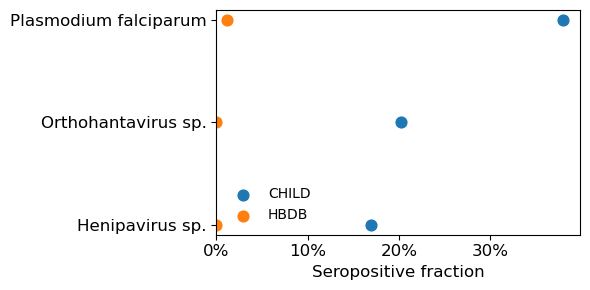

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(6, 3))

y = np.arange(len(plot_df))

ax.scatter(
    plot_df['CHILD'],
    y,
    s=60,
    label='CHILD'
)

ax.scatter(
    plot_df['HBDB'],
    y,
    s=60,
    label='HBDB'
)

ax.set_yticks(y)
ax.set_yticklabels(plot_df['species'])

ax.set_xlabel('Seropositive fraction', fontsize=12)
ax.set_ylabel('')

# Show as %
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f'{x:.0%}')
)

ax.set_xlim(left=0)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [ ]:
top_species = plot_df['species'].tolist()

protein_peptides = hits_specific[
    hits_specific['species'].isin(top_species)
].copy()

In [ ]:
protein_peptides

log_hbdb
log_mat

logrpk_concat = pd.concat([log_mat, log_hbdb], axis=1)

In [ ]:
# Top 15 peptides by fraction of CHILD reactive
protein_peptides_top = (
    protein_peptides
    .sort_values(
        by='frac_pass_z_in_CHILD',
        ascending=False
    )
    .head(10)
    .copy()
)

# Get their log10 RPK values
logrpk_concat_subset = logrpk_concat.loc[
    protein_peptides_top['peptide']
].copy()

# Long format
plot_data = (
    logrpk_concat_subset
    .reset_index()
    .melt(
        id_vars='peptide',
        var_name='individual',
        value_name='log10_RPK'
    )
)

# Add species
plot_data = plot_data.merge(
    protein_peptides_top[
        ['peptide', 'species']
    ].drop_duplicates('peptide'),
    on='peptide',
    how='left'
)

# Add cohort
plot_data['cohort'] = np.where(
    plot_data['individual'].str.startswith('CHILD-'),
    'CHILD',
    'HBDB'
)

# Short peptide label
plot_data['peptide_short'] = (
    plot_data['peptide']
    .str.split('|')
    .apply(lambda x: f'{x[0]} | {x[-1]}')
)

# Create peptide -> species label
plot_data['peptide_species_label'] = (
    plot_data['peptide_short']
    + '\n'
    + plot_data['species']
)


In [ ]:
z3_cutoff = (
    log_hbdb_mean
    + Z_THRESH * log_hbdb_std
)

In [ ]:
plot_data['z3_cutoff'] = plot_data['peptide'].map(z3_cutoff)

plot_data = plot_data.sort_values(
    ['species', 'peptide_short']
)

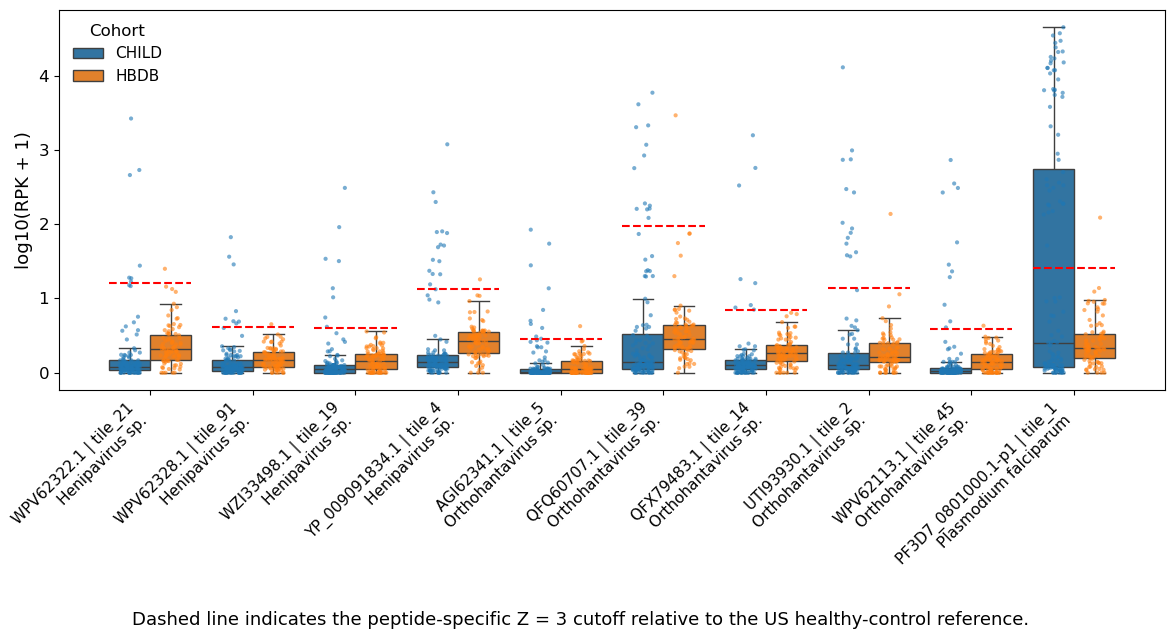

<Figure size 640x480 with 0 Axes>

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

# Boxplots
sns.boxplot(
    data=plot_data,
    x='peptide_species_label',
    y='log10_RPK',
    hue='cohort',
    showfliers=False,
    ax=ax
)

# Individual samples
sns.stripplot(
    data=plot_data,
    x='peptide_species_label',
    y='log10_RPK',
    hue='cohort',
    dodge=True,
    jitter=0.2,
    alpha=0.6,
    size=3,
    ax=ax
)
peptide_order = (
    plot_data[
        ['peptide', 'peptide_species_label']
    ]
    .drop_duplicates()
    ['peptide_species_label']
    .tolist()
)

for i, label in enumerate(peptide_order):

    cutoff = (
        plot_data.loc[
            plot_data['peptide_species_label'] == label,
            'z3_cutoff'
        ]
        .iloc[0]
    )

    ax.hlines(
        y=cutoff,
        xmin=i - 0.4,
        xmax=i + 0.4,
        color='red',
        linestyle='--',
        linewidth=1.5,
        zorder=5
    )
ax.set_xlabel('')
ax.set_ylabel('log10(RPK + 1)', fontsize=13)

ax.tick_params(axis='y', labelsize=12)

plt.xticks(
    rotation=45,
    ha='right',
    fontsize=11
)

# Remove duplicated legend entries
handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles[:2],
    labels[:2],
    title='Cohort',
    frameon=False,
    fontsize=11,
    title_fontsize=12
)

fig.text(
    0.5,
    -0.05,
    'Dashed line indicates the peptide-specific Z = 3 cutoff '
    'relative to the US healthy-control reference.',
    ha='center',
    fontsize=13
)

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

### protein map

In [ ]:
protein_name_map = {
    # Nucleoprotein / nucleocapsid
    'nucleocapsid': 'Nucleoprotein',
    'nucleocapsid protein': 'Nucleoprotein',
    'nucleoprotein': 'Nucleoprotein',

    # Glycoproteins
    'glycoprotein': 'Glycoprotein',
    'envelope glycoprotein': 'Glycoprotein',
    'fusion glycoprotein': 'Glycoprotein',
    'G1 and G2 proteins': 'Glycoprotein',

    # Glycoprotein precursor
    'glycoprotein precursor': 'Glycoprotein precursor',
    'envelope glycoprotein precursor': 'Glycoprotein precursor',
    'glycoproteins G1/G2 polypeptide': 'Glycoprotein precursor',
    'attachment glycoprotein': 'Glycoprotein precursor',

    # Polymerase
    'RNA-dependent RNA polymerase': 'RNA-dependent RNA polymerase',
    'polymerase': 'RNA-dependent RNA polymerase',
    'RNA polymerase' : 'RNA-dependent RNA polymerase',
    'RdRp' : 'RNA-dependent RNA polymerase',

    # Matrix
    'matrix protein': 'Matrix protein',

    # L / large protein
    'large protein': 'Large protein',

    # Phosphoprotein
    'phosphoprotein P': 'Phosphoprotein',
    'phosphoprotein': 'Phosphoprotein',

    # Others
    'PHISTc': 'PHISTc',
    'interspersed repeat antigen': 'Interspersed repeat antigen',
}

In [ ]:
protein_peptides['protein_standardized'] = (
    protein_peptides['protein_name']
    .map(protein_name_map)
    .fillna(protein_peptides['protein_name'])
)

In [ ]:
protein_peptides.loc[protein_peptides['species'] == 'Orthohantavirus sp.'].head(2)

,peptide,frac_pass_z_in_CHILD,frac_pass_z_in_US,sequence,species,genus,subfamily,family,order,protein_name,...,HBDB-106,HBDB-107,HBDB-109,HBDB-111,HBDB-115,cluster_id,cluster_size,n_species_in_cluster,is_species_specific_cluster,protein_standardized
1314,XBW52403.1|polymerase|Sager_Creek_orthohantavi...,0.032258,0.011364,RNYPETPVQKLVADMAYKYITLDKDDILNYYNPRAYFKQTANVKEP,Orthohantavirus sp.,Orthohantavirus,Mammantavirinae,Hantaviridae,Elliovirales,RNA polymerase,...,1.396062,-0.905084,0.684271,2.202125,0.725622,C0717,2,1,True,RNA-dependent RNA polymerase
1316,XBP46463.1|protein|Stubbeard_plunderfish_hanta...,0.024194,0.000000,DVCKEDLGLLRFTPAMKSAGTGGRMRIRGFGPGCDVVAQWCTYAVS,Orthohantavirus sp.,Orthohantavirus,Mammantavirinae,Hantaviridae,Elliovirales,matrix protein,...,0.000000,0.000000,0.000000,0.000000,0.000000,C0719,1,1,True,Matrix protein


In [ ]:
protein_matrix = (
    protein_peptides
    .groupby(['species', 'protein_standardized'])
    ['peptide']
    .nunique()
    .unstack(fill_value=0)
)

protein_matrix

protein_standardized,Glycoprotein,Glycoprotein precursor,L protein,Large protein,M polyprotein,Matrix protein,Nucleoprotein,PHISTc,Phosphoprotein,RNA-dependent RNA polymerase,nonstructural protein C
species,,,,,,,,,,,
Henipavirus sp.,3,1,1,5,0,2,7,0,11,13,1
Orthohantavirus sp.,10,15,0,0,1,1,13,0,0,29,0
Plasmodium falciparum,0,0,0,0,0,0,0,1,0,0,0


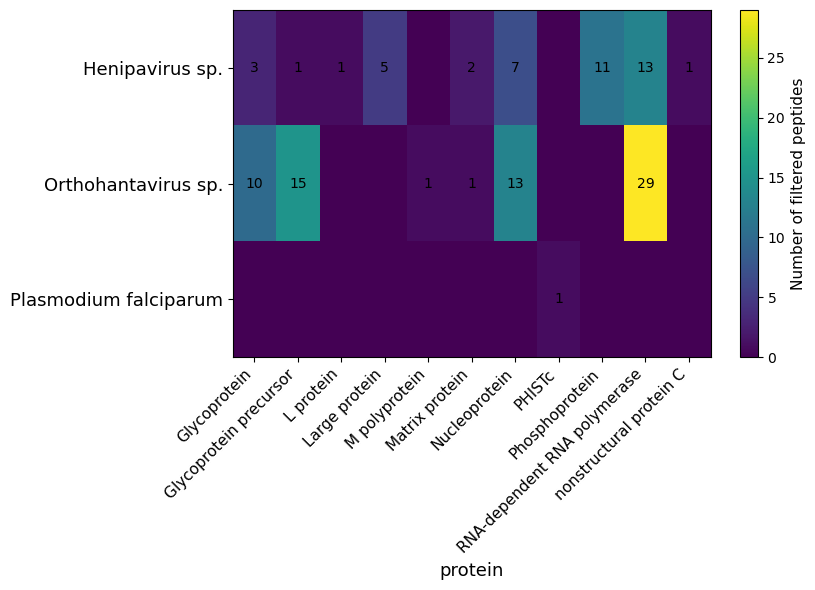

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8.5, 6))

im = ax.imshow(
    protein_matrix.values,
    aspect='auto'
)

ax.set_yticks(range(len(protein_matrix.index)))
ax.set_yticklabels(
    protein_matrix.index,
    fontsize=13
)

ax.set_xticks(range(len(protein_matrix.columns)))
ax.set_xticklabels(
    protein_matrix.columns,
    rotation=45,
    ha='right',
    fontsize=11
)

# Write number of peptides in each cell
for i in range(protein_matrix.shape[0]):
    for j in range(protein_matrix.shape[1]):

        value = protein_matrix.iloc[i, j]

        if value > 0:
            ax.text(
                j,
                i,
                int(value),
                ha='center',
                va='center'
            )

ax.set_xlabel('protein', fontsize=13)
ax.set_ylabel('')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Number of filtered peptides', fontsize=11)

plt.tight_layout()
plt.show()

### look at genus level

In [ ]:
cluster_genus = (
    hits_z
    .groupby('cluster_id')['genus']
    .nunique()
    .rename('n_genera')
)

hits_z['n_genera_in_cluster'] = (
    hits_z['cluster_id'].map(cluster_genus)
)

hits_z['is_genus_specific_cluster'] = (
    hits_z['n_genera_in_cluster'] == 1
)

hits_genus_specific = hits_z[
    hits_z['is_genus_specific_cluster']
].copy()

def calculate_genus_breadth(df, individual_cols, cohort):
    
    records = []

    for genus, genus_df in df.groupby('genus'):
        
        for individual in individual_cols:
            
            positive = genus_df[individual] > Z_THRESH
            
            breadth = genus_df.loc[
                positive,
                'cluster_id'
            ].nunique()
            
            records.append({
                'genus': genus,
                'individual': individual,
                'breadth': breadth,
                'cohort': cohort
            })
    
    return pd.DataFrame(records)

breadth_child_genus = calculate_genus_breadth(
    hits_genus_specific,
    child_cols,
    'CHILD'
)

breadth_hbdb_genus = calculate_genus_breadth(
    hits_genus_specific,
    hbdb_cols,
    'HBDB'
)

breadth_genus_df = pd.concat(
    [breadth_child_genus, breadth_hbdb_genus],
    ignore_index=True
)

# Determine minimum breadth threshold giving >=98% specificity in HBDB

threshold_records_genus = []

for genus, group in breadth_genus_df.groupby('genus'):

    hbdb = group[group['cohort'] == 'HBDB']

    max_breadth = int(hbdb['breadth'].max())

    for k in range(1, max_breadth + 2):

        n_positive = (hbdb['breadth'] >= k).sum()
        frac_positive = (hbdb['breadth'] >= k).mean()

        threshold_records_genus.append({
            'genus': genus,
            'breadth_threshold': k,
            'n_HBDB_positive': n_positive,
            'frac_HBDB_positive': frac_positive,
            'specificity': 1 - frac_positive
        })

threshold_genus_df = pd.DataFrame(threshold_records_genus)

genus_thresholds = (
    threshold_genus_df[
        threshold_genus_df['specificity'] >= 0.98
    ]
    .sort_values(['genus', 'breadth_threshold'])
    .drop_duplicates('genus', keep='first')
)

breadth_genus_df = breadth_genus_df.merge(
    genus_thresholds[
        ['genus', 'breadth_threshold']
    ],
    on='genus',
    how='left'
)

breadth_genus_df['seropositive'] = (
    breadth_genus_df['breadth']
    >= breadth_genus_df['breadth_threshold']
)

genus_seropositivity = (
    breadth_genus_df
    .groupby(['genus', 'cohort'])
    .agg(
        n_positive=('seropositive', 'sum'),
        n_total=('seropositive', 'size'),
        fraction_positive=('seropositive', 'mean')
    )
    .reset_index()
)

genus_wide = (
    genus_seropositivity
    .pivot(
        index='genus',
        columns='cohort',
        values='fraction_positive'
    )
    .reset_index()
)

genus_wide['delta'] = (
    genus_wide['CHILD'] - genus_wide['HBDB']
)

plot_genus = (
    genus_wide
    .sort_values('CHILD', ascending=False)
    .head(6)
    .sort_values('CHILD', ascending=True)
)


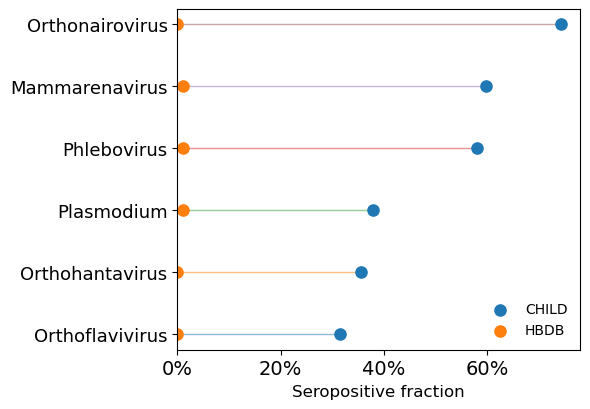

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(6, 4.2))

y = np.arange(len(plot_genus))

ax.scatter(
    plot_genus['CHILD'],
    y,
    s=65,
    label='CHILD'
)

ax.scatter(
    plot_genus['HBDB'],
    y,
    s=65,
    label='HBDB'
)

# Optional connecting lines
for i in range(len(plot_genus)):
    ax.plot(
        [plot_genus.iloc[i]['HBDB'],
         plot_genus.iloc[i]['CHILD']],
        [i, i],
        linewidth=1,
        alpha=0.5,
        zorder=0
    )

ax.set_yticks(y)
ax.set_yticklabels(plot_genus['genus'])

ax.set_xlabel('Seropositive fraction', fontsize=12)
ax.set_ylabel('')

ax.tick_params(
    axis='y',
    labelsize=17
)

ax.tick_params(
    axis='x',
    labelsize=14
)


ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f'{x:.0%}')
)

ax.set_xlim(left=0)

ax.tick_params(axis='y', labelsize=13)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [ ]:
median_breadth_genus = (
    breadth_genus_df[
        (breadth_genus_df['cohort'] == 'CHILD') &
        (breadth_genus_df['seropositive'])
    ]
    .groupby('genus')
    .agg(
        median_breadth=('breadth', 'median'),
        mean_breadth=('breadth', 'mean'),
        n_seropositive=('individual', 'nunique')
    )
    .reset_index()
)

In [ ]:
plot_genus = plot_genus.merge(
    median_breadth_genus,
    on='genus',
    how='left'
)

In [ ]:
plot_genus[
    [
        'genus',
        'CHILD',
        'HBDB',
        'median_breadth',
        'n_seropositive'
    ]
]

,genus,CHILD,HBDB,median_breadth,n_seropositive
0,Orthoflavivirus,0.314516,0.000000,4.0,39
1,Orthohantavirus,0.354839,0.000000,6.0,44
2,Plasmodium,0.379032,0.011364,1.0,47
3,Phlebovirus,0.580645,0.011364,11.0,72
4,Mammarenavirus,0.596774,0.011364,9.5,74
5,Orthonairovirus,0.741935,0.000000,14.0,92


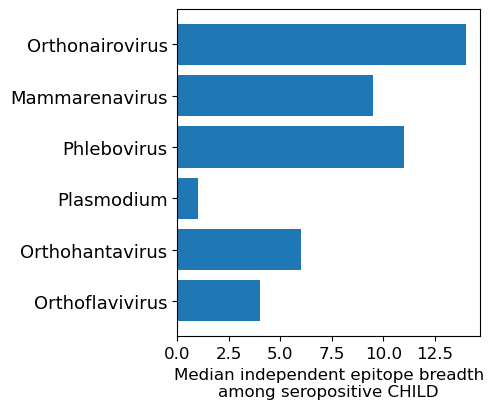

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4.2))

ax.barh(
    plot_genus['genus'],
    plot_genus['median_breadth']
)

ax.set_xlabel(
    'Median independent epitope breadth\namong seropositive CHILD',
    fontsize=12
)

ax.set_ylabel('')

ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=13)

plt.tight_layout()
plt.show()

### final figure for clusters

In [ ]:
cluster_summary = (
    hits_z
    .groupby('cluster_id')
    .agg(
        n_peptides=('peptide', 'nunique'),
        n_species=('species', 'nunique'),
        n_genera=('genus', 'nunique'),
        n_families=('family', 'nunique')
    )
    .reset_index()
)

In [ ]:
def classify_cluster(row):

    if row['n_peptides'] == 1:
        return 'Singleton'

    elif row['n_species'] == 1:
        return 'Within species'

    elif row['n_genera'] == 1:
        return 'Cross-species\nwithin genus'

    elif row['n_families'] == 1:
        return 'Cross-genus\nwithin family'

    else:
        return 'Cross-family'


cluster_summary['cluster_type'] = (
    cluster_summary.apply(
        classify_cluster,
        axis=1
    )
)

In [ ]:
cluster_summary['cluster_type'].value_counts()

cluster_type
Singleton                      823
Cross-species\nwithin genus    173
Within species                 101
Cross-genus\nwithin family      33
Cross-family                     4
Name: count, dtype: int64

In [ ]:
cluster_counts = (
    cluster_summary['cluster_type']
    .value_counts()
    .reindex([
        'Singleton',
        'Within species',
        'Cross-species\nwithin genus',
        'Cross-genus\nwithin family',
        'Cross-family'
    ])
    .fillna(0)
)

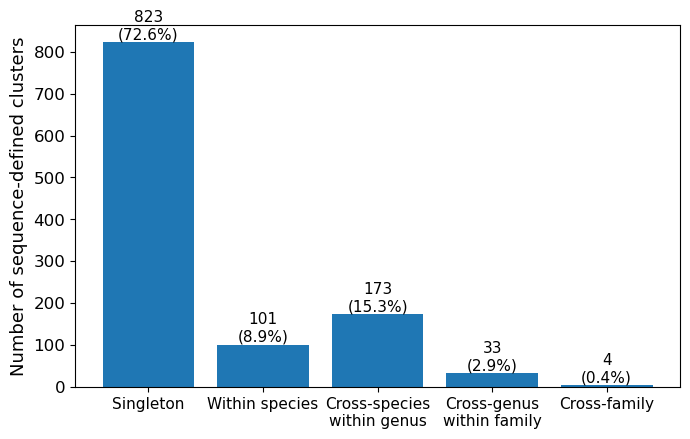

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4.5))

bars = ax.bar(
    cluster_counts.index,
    cluster_counts.values
)

ax.set_ylabel(
    'Number of sequence-defined clusters',
    fontsize=13
)

ax.set_xlabel('')

ax.tick_params(
    axis='x',
    labelsize=11
)

ax.tick_params(
    axis='y',
    labelsize=12
)



cluster_pct = (
    cluster_counts /
    cluster_counts.sum() * 100
)

cluster_pct

for bar, pct in zip(bars, cluster_pct):

    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}\n({pct:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.tight_layout()
plt.show()

In [ ]:
example_clusters = (
    hits_z
    .groupby('cluster_id')
    .agg(
        n_peptides=('peptide', 'nunique'),
        n_species=('species', 'nunique'),
        n_genera=('genus', 'nunique'),
        species=('species', lambda x: list(x.unique())),
        genera=('genus', lambda x: list(x.unique()))
    )
    .reset_index()
)

example_clusters[
    (example_clusters['n_species'] > 1) &
    (example_clusters['n_genera'] == 1)
].sort_values(
    ['n_species', 'n_peptides'],
    ascending=False
).head(15)

,cluster_id,n_peptides,n_species,n_genera,species,genera
840,C0841,13,11,1,"[Yunnan rodent phlebovirus 1, Mudanjiang phleb...",[Phlebovirus]
17,C0018,12,10,1,"[Pannonia mammarenavirus, Mammarenavirus chori...",[Mammarenavirus]
79,C0080,11,10,1,"[Mammarenavirus guanaritoense, Mammarenavirus ...",[Mammarenavirus]
876,C0877,9,9,1,"[Phlebovirus embossosense, Phlebovirus pantana...",[Phlebovirus]
842,C0843,10,8,1,"[Yunnan rodent phlebovirus 1, Phlebovirus flor...",[Phlebovirus]
13,C0014,14,7,1,"[Mammarenavirus mecsekense, Pannonia mammarena...",[Mammarenavirus]
70,C0071,14,7,1,"[Reptarenavirus rotterdamense, Saudades virus ...",[Reptarenavirus]
43,C0044,11,7,1,"[Mammarenavirus choriomeningitidis, Mammarenav...",[Mammarenavirus]
868,C0869,11,7,1,"[Echarate-like virus Chanchamayo-2019, Phlebov...",[Phlebovirus]
890,C0891,9,7,1,"[Phlebovirus cocleense, Phlebovirus claroense,...",[Phlebovirus]


In [ ]:
example_cluster_id = 'C0698'   # replace with one you like

In [ ]:
cluster = hits_z[
    hits_z['cluster_id'] == example_cluster_id
][
    ['peptide', 'sequence', 'species', 'genus', 'protein_name']
].drop_duplicates()

cluster

,peptide,sequence,species,genus,protein_name
1283,XQU63515.1|polymerase|Altai_virus|isolate=SO5_...,AIKKIEKMHVPNHPTGKTYKSFFKMTPDNYRIEGSKILFKEVTVTS,Altai virus,Orthohantavirus,RNA-dependent RNA polymerase
1295,XHP16120.1|polymerase|Orthohantavirus_hantanen...,KMTPDNYKISGTTIEFVEVTVTADVDKGIREKKLKYEAGLTYIEQE,Orthohantavirus hantanense,Orthohantavirus,RNA-dependent RNA polymerase
1310,XAL72294.1|polymerase|Orthohantavirus_sinnombr...,RLTPDNYKITGALIEFIEVTVTADVAKGIREKKLKYESGLQFIESL,Orthohantavirus sinnombreense,Orthohantavirus,RNA polymerase
1339,WKR44731.1|polymerase|Limestone_Canyon_virus|i...,LRSFFKMTPDNYKITGNLIEFVEVTVTADVARGIREKKMKYEGGLQ,Orthohantavirus sp.,Orthohantavirus,RNA-dependent RNA polymerase
1351,YP_010839931.1|polymerase|Xuan_son_virus|isola...,VLTRMEKRVIPNHPTGKTLKNFFKMTPDNYKITGQHIEFKEVTVTS,Mobatvirus xuansonense,Orthohantavirus,RNA-dependent RNA polymerase
1446,YP_009362032.1|polymerase|Nova_virus|isolate=?...,WSDNKDKETPIVTVLMQAGISDNSLGLIEKVVIPDHPTGKNLGAFM,Mobatvirus novaense,Orthohantavirus,RNA-dependent RNA polymerase
1447,YP_009362032.1|polymerase|Nova_virus|isolate=?...,SLGLIEKVVIPDHPTGKNLGAFMKTTPDNYKIEGSKITFIEVTVTS,Mobatvirus novaense,Orthohantavirus,RNA-dependent RNA polymerase


In [ ]:
from itertools import combinations

motif_records = []

for (idx1, row1), (idx2, row2) in combinations(
    cluster.iterrows(), 2
):

    kmers1 = get_7mers(row1['sequence'])
    kmers2 = get_7mers(row2['sequence'])

    shared = kmers1 & kmers2

    for motif in sorted(shared):

        motif_records.append({
            'peptide_1': row1['peptide'],
            'peptide_2': row2['peptide'],
            'species_1': row1['species'],
            'species_2': row2['species'],
            'motif': motif
        })

motif_df = pd.DataFrame(motif_records)

motif_df['motif'].unique()

NameError: name 'get_7mers' is not defined

In [ ]:
example = hits_z[
    hits_z['cluster_id'] == example_cluster_id
][
    [
        'peptide',
        'sequence',
        'species',
        'genus',
        'family',
        'protein_name'
    ]
].drop_duplicates()

example

,peptide,sequence,species,genus,family,protein_name
1283,XQU63515.1|polymerase|Altai_virus|isolate=SO5_...,AIKKIEKMHVPNHPTGKTYKSFFKMTPDNYRIEGSKILFKEVTVTS,Altai virus,Orthohantavirus,Hantaviridae,RNA-dependent RNA polymerase
1295,XHP16120.1|polymerase|Orthohantavirus_hantanen...,KMTPDNYKISGTTIEFVEVTVTADVDKGIREKKLKYEAGLTYIEQE,Orthohantavirus hantanense,Orthohantavirus,Hantaviridae,RNA-dependent RNA polymerase
1310,XAL72294.1|polymerase|Orthohantavirus_sinnombr...,RLTPDNYKITGALIEFIEVTVTADVAKGIREKKLKYESGLQFIESL,Orthohantavirus sinnombreense,Orthohantavirus,Hantaviridae,RNA polymerase
1339,WKR44731.1|polymerase|Limestone_Canyon_virus|i...,LRSFFKMTPDNYKITGNLIEFVEVTVTADVARGIREKKMKYEGGLQ,Orthohantavirus sp.,Orthohantavirus,Hantaviridae,RNA-dependent RNA polymerase
1351,YP_010839931.1|polymerase|Xuan_son_virus|isola...,VLTRMEKRVIPNHPTGKTLKNFFKMTPDNYKITGQHIEFKEVTVTS,Mobatvirus xuansonense,Orthohantavirus,Hantaviridae,RNA-dependent RNA polymerase
1446,YP_009362032.1|polymerase|Nova_virus|isolate=?...,WSDNKDKETPIVTVLMQAGISDNSLGLIEKVVIPDHPTGKNLGAFM,Mobatvirus novaense,Orthohantavirus,Hantaviridae,RNA-dependent RNA polymerase
1447,YP_009362032.1|polymerase|Nova_virus|isolate=?...,SLGLIEKVVIPDHPTGKNLGAFMKTTPDNYKIEGSKITFIEVTVTS,Mobatvirus novaense,Orthohantavirus,Hantaviridae,RNA-dependent RNA polymerase
